# Pareto Analysis       

The aim of this project is to find out what revenue percentage comes from which percentage of customers.
using the petshop csv file located in the folder "data"      


Description of columns: 

**InvoiceNo** -          Unique ID for each transaction   

**StockCode** -            Unique product/item identifier    

**Description** -          Human-readable product name     

**InvoiceDate** -          Date & time the transaction was made   

**CustomerID** -          Unique identifier for each customer     

**Quantity** -            Number of units bought  

**UnitPrice** -           Price per single unit in 

**Country**  -             Country where the customer is based

In [11]:
# install packages 
#%pip install pyodbc sqlalchemy pandas matplotlib seaborn

#### Import Libraries

In [18]:
import pandas as pd
from sqlalchemy import create_engine 
import urllib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#### Connect to SQLSERVER DataBase

In [19]:
# building the connection string
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=LOCALHOST;"
    "DATABASE=petshop;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


### Pareto Analysis

In [20]:
query = '''
    WITH customer_sales AS (
    SELECT 
        CustomerID, 
        SUM(Quantity * UnitPrice) AS customer_revenue
    FROM sales
    WHERE Quantity > 0 AND UnitPrice > 0
    GROUP BY CustomerID
    ),
    ranked_by_revenue AS (
        SELECT 
            CustomerID, 
            customer_revenue,
            ROW_NUMBER() OVER (ORDER BY customer_revenue DESC) AS rank_customer,
            COUNT(*) OVER () AS total_customers,
            SUM(customer_revenue) OVER (
                ORDER BY customer_revenue DESC 
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cum_revenue,
            SUM(customer_revenue) OVER () AS total_revenue
        FROM customer_sales
    )
    SELECT 
        rank_customer,
        total_customers,
        customer_revenue,
        cum_revenue,
        total_revenue,
        cum_revenue / total_revenue                    AS cum_sales_share,
        rank_customer / CAST(total_customers AS FLOAT) AS cum_pct_customers
    FROM ranked_by_revenue
    ORDER BY rank_customer;
'''


df = pd.read_sql(query, engine)

print(f"✅Rows Loaded: {len(df)} ")
print(f"✅Total Customers: {df['total_customers'].iloc[0]} ")
df.head()

✅Rows Loaded: 261 
✅Total Customers: 261 


,rank_customer,total_customers,customer_revenue,cum_revenue,total_revenue,cum_sales_share,cum_pct_customers
0,1,261,1100.40,1100.40,116490.24,0.009446,0.003831
1,2,261,992.55,2092.95,116490.24,0.017966,0.007663
2,3,261,977.45,3070.40,116490.24,0.026357,0.011494
3,4,261,955.82,4026.22,116490.24,0.034562,0.015326
4,5,261,909.61,4935.83,116490.24,0.042371,0.019157


### Visualizing the Pareto Chart        

This classical pareto Chart has:   
* Bars ->  Each customer's individual revenue (left axis)
* Line ->  cumulative revenue % curve (right axis)
* Reference Lines -> target + crossing point 

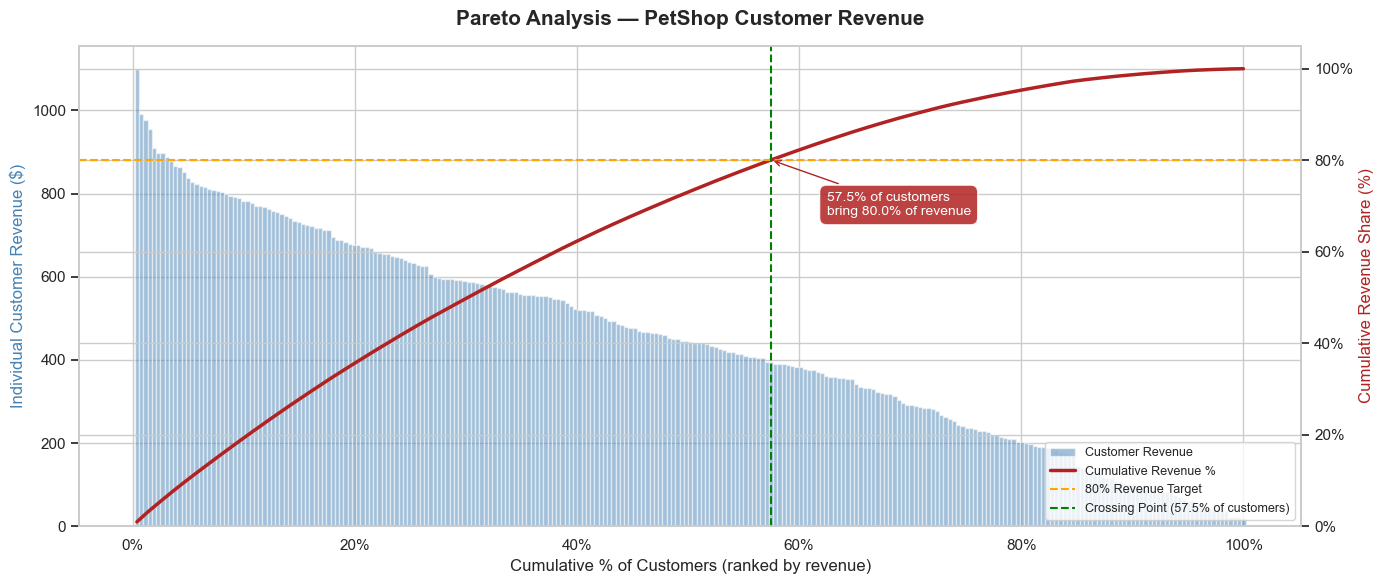

In [25]:
sns.set_theme(style="whitegrid")
PCT_TARGET = 0.80

# find the crossing point 
crossing = df[df['cum_sales_share'] >= PCT_TARGET].iloc[0]
cross_x = crossing['cum_pct_customers'] 
cross_y = crossing['cum_sales_share']

# Dual Axis figure
fig, ax1 = plt.subplots(figsize=(14,6))
ax2 = ax1.twinx()

ax1.bar(
    df['cum_pct_customers'],         
    df['customer_revenue'],           
    width=1 / len(df),                
    color='steelblue',
    alpha=0.5,
    label='Customer Revenue'
)

ax2.plot(
    df['cum_pct_customers'],
    df['cum_sales_share'],
    color='firebrick',
    linewidth=2.5,
    label='Cumulative Revenue %'
)

ax2.axhline(y=PCT_TARGET, color='orange', linestyle='--', linewidth=1.5, label=f'{int(PCT_TARGET*100)}% Revenue Target')
ax2.axvline(x=cross_x, color='green', linestyle='--', linewidth=1.5, label=f'Crossing Point ({cross_x:.1%} of customers)')

ax2.annotate(
    f"{cross_x:.1%} of customers\nbring {cross_y:.1%} of revenue",
    xy=(cross_x, cross_y),
    xytext=(cross_x + 0.05, cross_y - 0.12),
    fontsize=10,
    color='white',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='firebrick', alpha=0.85),
    arrowprops=dict(arrowstyle='->', color='firebrick')
)


ax1.set_xlabel('Cumulative % of Customers (ranked by revenue)', fontsize=12)
ax1.set_ylabel('Individual Customer Revenue ($)', fontsize=12, color='steelblue')
ax2.set_ylabel('Cumulative Revenue Share (%)', fontsize=12, color='firebrick')

ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.title('Pareto Analysis — PetShop Customer Revenue', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('pareto_petshop.png', dpi=150)  # saves a crisp PNG
plt.show()
